# Jackson 2.3: Line Charge Near Intersecting Grounded Planes

This notebook reproduces the main results of Jackson Chapter 2, Problem 2.3 for a straight line charge placed in the first quadrant between two grounded conducting half-planes.

The geometry is two-dimensional in the $(x,y)$ plane, with the actual line charge running parallel to the $z$ axis. A line charge of strength $\lambda$ sits at $(x_0,y_0)$ with $x_0>0$ and $y_0>0$. The boundaries are the grounded conductors

$$
x=0,\; y\ge 0,
\qquad
y=0,\; x\ge 0.
$$

The goals are:

1. derive the potential with the method of images,
2. verify that the boundary potential and tangential fields vanish,
3. compute and plot the induced surface charge density,
4. integrate the surface charge to get the total induced charge on each plane,
5. and examine the far-field asymptotic form of the potential.


## Method of Images

To satisfy both grounded boundaries we place three image line charges in addition to the physical line charge:

- $+\lambda$ at $(x_0,y_0)$,
- $-\lambda$ at $(-x_0,y_0)$,
- $-\lambda$ at $(x_0,-y_0)$,
- $+\lambda$ at $(-x_0,-y_0)$.

If we define the squared distances

$$
r_1^2=(x-x_0)^2+(y-y_0)^2,
\qquad
r_2^2=(x+x_0)^2+(y-y_0)^2,
$$

$$
r_3^2=(x-x_0)^2+(y+y_0)^2,
\qquad
r_4^2=(x+x_0)^2+(y+y_0)^2,
$$

then the total potential in the physical first quadrant is

$$
\Phi(x,y)=\frac{\lambda}{4\pi\varepsilon_0}\ln\left(\frac{r_2^2r_3^2}{r_1^2r_4^2}\right).
$$

This automatically vanishes on both boundaries because at $x=0$ one has $r_1=r_2$ and $r_3=r_4$, while at $y=0$ one has $r_1=r_3$ and $r_2=r_4$.

Differentiating gives the electric field components,

$$
E_x=-\frac{\partial \Phi}{\partial x},
\qquad
E_y=-\frac{\partial \Phi}{\partial y}.
$$

The tangential field on $y=0$ is $E_x$, and the tangential field on $x=0$ is $E_y$. Both should vanish if the grounded-conductor boundary condition is satisfied correctly.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

plt.style.use("seaborn-v0_8-whitegrid")


In [1]:
eps0 = 1.0
lam = 1.0
x0_demo = 1.25
y0_demo = 0.75


def squared_distances(x, y, x0, y0):
    r1_sq = (x - x0)**2 + (y - y0)**2
    r2_sq = (x + x0)**2 + (y - y0)**2
    r3_sq = (x - x0)**2 + (y + y0)**2
    r4_sq = (x + x0)**2 + (y + y0)**2
    return r1_sq, r2_sq, r3_sq, r4_sq


def potential_wedge(x, y, x0, y0, lam=1.0, eps0=1.0):
    r1_sq, r2_sq, r3_sq, r4_sq = squared_distances(x, y, x0, y0)
    return (lam / (4.0 * np.pi * eps0)) * np.log((r2_sq * r3_sq) / (r1_sq * r4_sq))


def electric_field_wedge(x, y, x0, y0, lam=1.0, eps0=1.0):
    r1_sq, r2_sq, r3_sq, r4_sq = squared_distances(x, y, x0, y0)
    prefactor = -lam / (2.0 * np.pi * eps0)
    ex = prefactor * (
        (x + x0) / r2_sq + (x - x0) / r3_sq - (x - x0) / r1_sq - (x + x0) / r4_sq
    )
    ey = prefactor * (
        (y - y0) / r2_sq + (y + y0) / r3_sq - (y - y0) / r1_sq - (y + y0) / r4_sq
    )
    return ex, ey


def sigma_on_y0(x, x0, y0, lam=1.0):
    return -(lam * y0 / np.pi) * (
        1.0 / ((x - x0)**2 + y0**2) - 1.0 / ((x + x0)**2 + y0**2)
    )


def sigma_on_x0(y, x0, y0, lam=1.0):
    return -(lam * x0 / np.pi) * (
        1.0 / ((y - y0)**2 + x0**2) - 1.0 / ((y + y0)**2 + x0**2)
    )


def total_charge_on_y0(x0, y0, lam=1.0):
    return -(2.0 * lam / np.pi) * np.arctan(x0 / y0)


def total_charge_on_x0(x0, y0, lam=1.0):
    return -(2.0 * lam / np.pi) * np.arctan(y0 / x0)


def phi_asymptotic(x, y, x0, y0, lam=1.0, eps0=1.0):
    rho_sq = x**2 + y**2
    return (4.0 * lam / (np.pi * eps0)) * (x0 * y0 * x * y) / (rho_sq**2)


## Boundary Verification

The boundary conditions require

$$
\Phi(0,y)=0,
\qquad
\Phi(x,0)=0,
$$

and the tangential field must vanish on each conductor:

$$
E_y(0,y)=0 \quad \text{on } x=0,
\qquad
E_x(x,0)=0 \quad \text{on } y=0.
$$


In [3]:
x_line = np.linspace(0.0, 4.0, 600)
y_line = np.linspace(0.0, 4.0, 600)

phi_on_y0 = potential_wedge(x_line, 0.0, x0_demo, y0_demo, lam=lam, eps0=eps0)
phi_on_x0 = potential_wedge(0.0, y_line, x0_demo, y0_demo, lam=lam, eps0=eps0)
ex_on_y0, ey_on_y0 = electric_field_wedge(x_line, 0.0, x0_demo, y0_demo, lam=lam, eps0=eps0)
ex_on_x0, ey_on_x0 = electric_field_wedge(0.0, y_line, x0_demo, y0_demo, lam=lam, eps0=eps0)

print(f"max |Phi(x,0)| = {np.max(np.abs(phi_on_y0)):.3e}")
print(f"max |Phi(0,y)| = {np.max(np.abs(phi_on_x0)):.3e}")
print(f"max |E_x(x,0)|  = {np.max(np.abs(ex_on_y0)):.3e}")
print(f"max |E_y(0,y)|  = {np.max(np.abs(ey_on_x0)):.3e}")


max |Phi(x,0)| = 0.000e+00
max |Phi(0,y)| = 0.000e+00
max |E_x(x,0)|  = 8.835e-18
max |E_y(0,y)|  = 8.835e-18


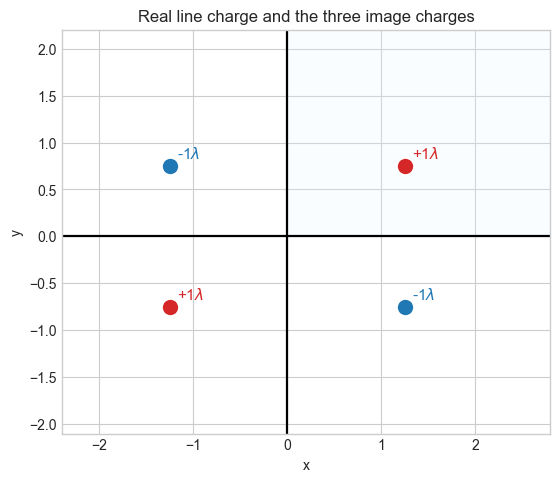

In [4]:
fig, ax = plt.subplots(figsize=(6.3, 6.0))
charges = np.array([
    [x0_demo, y0_demo, +1.0],
    [-x0_demo, y0_demo, -1.0],
    [x0_demo, -y0_demo, -1.0],
    [-x0_demo, -y0_demo, +1.0],
])

for xq, yq, sign in charges:
    color = "tab:red" if sign > 0 else "tab:blue"
    marker = "+" if sign > 0 else "_"
    ax.scatter(xq, yq, s=150, color=color, marker="o", edgecolor="white", linewidth=1.2, zorder=3)
    ax.text(xq + 0.08, yq + 0.08, f"{sign:+.0f}$\\lambda$", color=color, fontsize=11)

ax.axhline(0.0, color="black", lw=1.6)
ax.axvline(0.0, color="black", lw=1.6)
ax.fill_between([0, 3.0], 0, 3.0, color="#e9f6ff", alpha=0.22)
ax.set_xlim(-2.4, 2.8)
ax.set_ylim(-2.1, 2.2)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Real line charge and the three image charges")
plt.show()


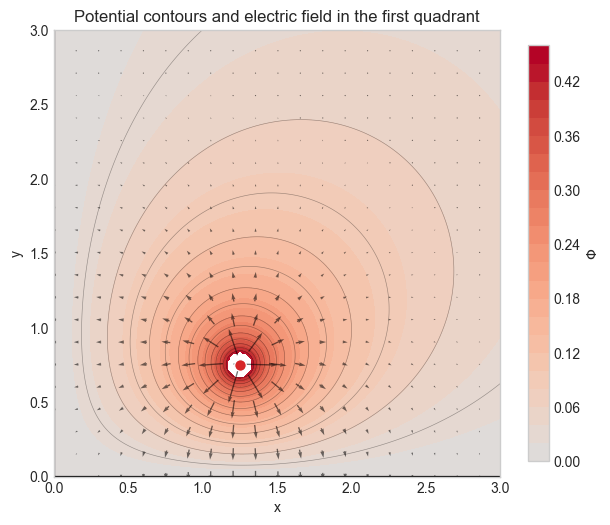

In [5]:
x = np.linspace(0.0, 3.0, 240)
y = np.linspace(0.0, 3.0, 240)
X, Y = np.meshgrid(x, y, indexing="xy")
Phi = potential_wedge(X, Y, x0_demo, y0_demo, lam=lam, eps0=eps0)
Ex, Ey = electric_field_wedge(X, Y, x0_demo, y0_demo, lam=lam, eps0=eps0)

source_radius = np.hypot(X - x0_demo, Y - y0_demo)
mask = source_radius < 0.08
Phi = np.where(mask, np.nan, Phi)
Ex = np.where(mask, np.nan, Ex)
Ey = np.where(mask, np.nan, Ey)

vmax = np.nanmax(np.abs(Phi))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

fig, ax = plt.subplots(figsize=(7.2, 6.0))
im = ax.contourf(X, Y, Phi, levels=22, cmap="coolwarm", norm=norm)
ax.contour(X, Y, Phi, levels=16, colors="black", linewidths=0.45, alpha=0.35)

step = 12
ax.quiver(
    X[::step, ::step],
    Y[::step, ::step],
    Ex[::step, ::step],
    Ey[::step, ::step],
    color="black",
    alpha=0.55,
    pivot="mid",
    scale=15.0,
)

ax.axhline(0.0, color="black", lw=1.6)
ax.axvline(0.0, color="black", lw=1.6)
ax.scatter([x0_demo], [y0_demo], s=70, color="tab:red", edgecolor="white", linewidth=0.9)
ax.set_xlim(0.0, 3.0)
ax.set_ylim(0.0, 3.0)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Potential contours and electric field in the first quadrant")
fig.colorbar(im, ax=ax, shrink=0.9, label=r"$\Phi$")
plt.show()


## Surface Charge Density and Total Induced Charge

The conductor surface charge density follows from the normal-field discontinuity. On the plane $y=0$ we use

$$
\sigma(x)=\varepsilon_0 E_y(x,0^+),
$$

which gives

$$
\sigma(x)=-\frac{\lambda y_0}{\pi}\left[\frac{1}{(x-x_0)^2+y_0^2}-\frac{1}{(x+x_0)^2+y_0^2}\right].
$$

Integrating this from $x=0$ to $\infty$ gives the total induced charge per unit length in $z$ on the plane $y=0$:

$$
Q_{y=0}=-\frac{2\lambda}{\pi}\tan^{-1}\left(\frac{x_0}{y_0}\right).
$$

By symmetry, the total induced charge on the plane $x=0$ is

$$
Q_{x=0}=-\frac{2\lambda}{\pi}\tan^{-1}\left(\frac{y_0}{x_0}\right).
$$

These add to $-\lambda$, so the two grounded surfaces together carry the total induced charge needed to neutralize the physical line charge.


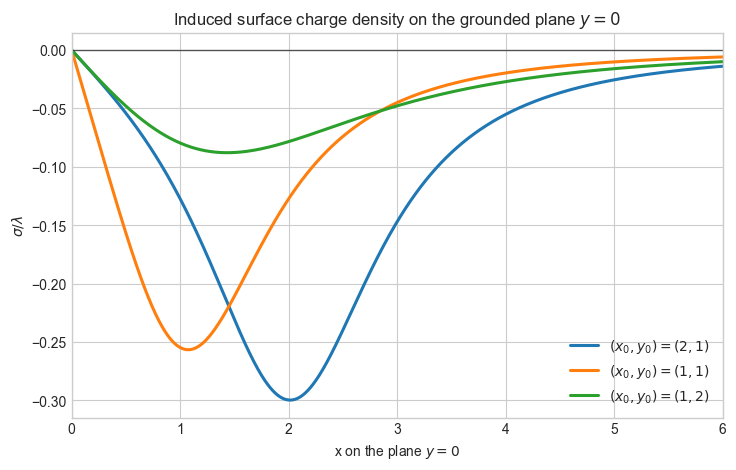

In [6]:
x_plot = np.linspace(0.0, 6.0, 900)
cases = [
    (2.0, 1.0),
    (1.0, 1.0),
    (1.0, 2.0),
]

fig, ax = plt.subplots(figsize=(8.4, 5.0))
for x0_case, y0_case in cases:
    ax.plot(
        x_plot,
        sigma_on_y0(x_plot, x0_case, y0_case, lam=lam) / lam,
        lw=2.2,
        label=fr"$(x_0,y_0)=({x0_case:.0f},{y0_case:.0f})$",
    )
ax.axhline(0.0, color="black", lw=1.0, alpha=0.6)
ax.set_xlim(0.0, 6.0)
ax.set_xlabel("x on the plane $y=0$")
ax.set_ylabel(r"$\sigma/\lambda$")
ax.set_title("Induced surface charge density on the grounded plane $y=0$")
ax.legend()
plt.show()


In [7]:
integration_grid = np.linspace(0.0, 250.0, 200000)
print("Numerical and analytic total induced charges")
print("=" * 60)
for x0_case, y0_case in cases:
    q_y_num = np.trapezoid(sigma_on_y0(integration_grid, x0_case, y0_case, lam=lam), integration_grid)
    q_y_exact = total_charge_on_y0(x0_case, y0_case, lam=lam)
    q_x_num = np.trapezoid(sigma_on_x0(integration_grid, x0_case, y0_case, lam=lam), integration_grid)
    q_x_exact = total_charge_on_x0(x0_case, y0_case, lam=lam)
    print(f"(x0, y0) = ({x0_case:.1f}, {y0_case:.1f})")
    print(f"  Q_y=0 numeric = {q_y_num:+.6f}, exact = {q_y_exact:+.6f}")
    print(f"  Q_x=0 numeric = {q_x_num:+.6f}, exact = {q_x_exact:+.6f}")
    print(f"  total induced charge = {q_y_exact + q_x_exact:+.6f}")


Numerical and analytic total induced charges
(x0, y0) = (2.0, 1.0)
  Q_y=0 numeric = -0.704812, exact = -0.704833
  Q_x=0 numeric = -0.295147, exact = -0.295167
  total induced charge = -1.000000
(x0, y0) = (1.0, 1.0)
  Q_y=0 numeric = -0.499990, exact = -0.500000
  Q_x=0 numeric = -0.499990, exact = -0.500000
  total induced charge = -1.000000
(x0, y0) = (1.0, 2.0)
  Q_y=0 numeric = -0.295147, exact = -0.295167
  Q_x=0 numeric = -0.704812, exact = -0.704833
  total induced charge = -1.000000


## Far-Field Asymptotic Form

Far from the origin, with $\rho=\sqrt{x^2+y^2}\gg \rho_0=\sqrt{x_0^2+y_0^2}$, the leading term of the potential is

$$
\Phi_{\rm asym}(x,y)=\frac{4\lambda}{\pi\varepsilon_0}\frac{(x_0y_0)(xy)}{\rho^4}.
$$

This decays like $1/\rho^2$ in the two-dimensional problem and has the angular structure expected of a quadrupole. That makes physical sense: the image construction contains four line charges with zero net charge and zero dipole moment, so the first surviving far-field term is quadrupolar.


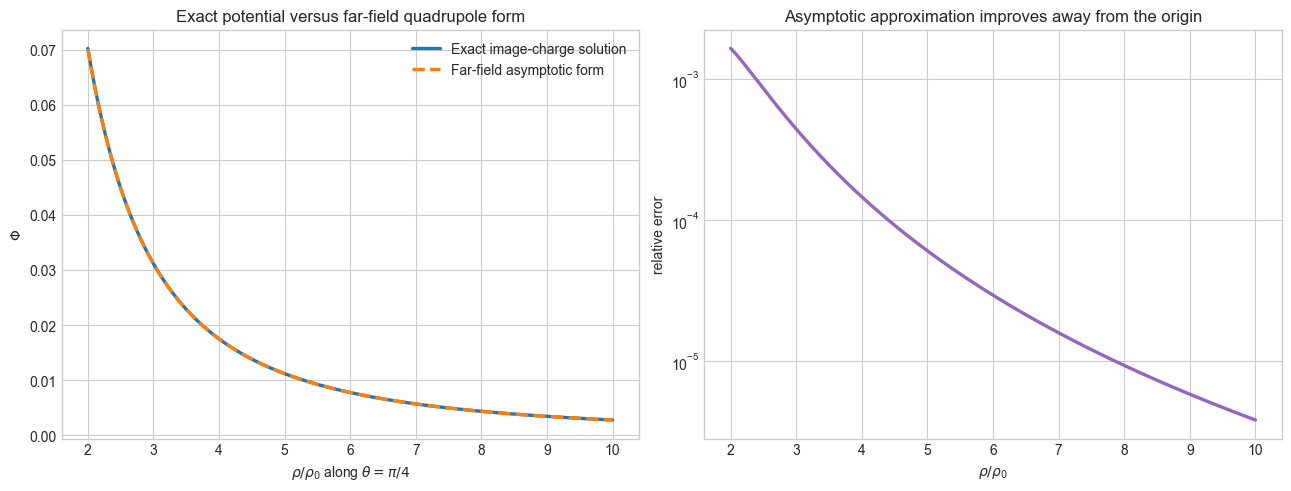

max relative error for rho >= 4 rho0: 1.450e-04


In [8]:
rho0 = np.hypot(x0_demo, y0_demo)
theta = np.pi / 4.0
rho_values = np.linspace(2.0 * rho0, 10.0 * rho0, 300)
x_ray = rho_values * np.cos(theta)
y_ray = rho_values * np.sin(theta)

phi_exact = potential_wedge(x_ray, y_ray, x0_demo, y0_demo, lam=lam, eps0=eps0)
phi_far = phi_asymptotic(x_ray, y_ray, x0_demo, y0_demo, lam=lam, eps0=eps0)
relative_error = np.abs(phi_far - phi_exact) / np.maximum(np.abs(phi_exact), 1.0e-14)

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8), constrained_layout=True)
axes[0].plot(rho_values / rho0, phi_exact, lw=2.4, label="Exact image-charge solution")
axes[0].plot(rho_values / rho0, phi_far, lw=2.4, ls="--", label="Far-field asymptotic form")
axes[0].set_xlabel(r"$\rho/\rho_0$ along $\theta=\pi/4$")
axes[0].set_ylabel(r"$\Phi$")
axes[0].set_title("Exact potential versus far-field quadrupole form")
axes[0].legend()

axes[1].semilogy(rho_values / rho0, relative_error, color="tab:purple", lw=2.4)
axes[1].set_xlabel(r"$\rho/\rho_0$")
axes[1].set_ylabel("relative error")
axes[1].set_title("Asymptotic approximation improves away from the origin")

plt.show()
print(f"max relative error for rho >= 4 rho0: {relative_error[rho_values >= 4.0 * rho0].max():.3e}")


## Summary

The method of images converts the wedge problem into a four-line-charge configuration whose symmetry enforces the grounded boundary conditions. The surface charge density is strongest near the point on each conductor closest to the physical line charge, and the two conducting planes share the total induced charge in a geometry-dependent way. Far away, the potential looks quadrupolar because the lower multipole moments cancel in the four-charge arrangement.
